# Hex tessellation — German waters zoom

Same unified grid as `003_HexTessellation_Baltic`, filtered to the German-waters
box. Two figsize variants per resolution (4×4 and 6×6 inch) to judge detail
density at both display sizes.

In [1]:
from pathlib import Path
data_root = Path("../../data")

# Unified HexProj origin — identical to 003.
hp_origin = dict(projection_name="laea", lon_origin=18.0, lat_origin=59.0)
candidate_radii_m = [4_000, 6_000, 10_000]

# German waters viz extent.
lon_min, lon_max = 8, 15
lat_min, lat_max = 53.2, 55.5

In [2]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.ops import unary_union
from shapely.geometry import box as shapely_box

from hextraj import HexProj

## Load data

In [3]:
wet_gdf = gpd.read_file(data_root / "BSH_model_coastline" / "coastline.geojson")
always_wet_gdf = gpd.read_file(data_root / "BSH_model_coastline" / "coastline_always_wet.geojson")
fucus_gdf = (
    gpd.read_file(data_root / "Fucus_location_shp" / "REDLIST_SIS_Macrophytes.shp")
    .query("F_vesiculo != 0")
    .to_crs(epsg=4326)
)

print(f"wet polygons: {len(wet_gdf)}")
print(f"always-wet polygons: {len(always_wet_gdf)}")
print(f"Fucus release cells: {len(fucus_gdf)}")

wet polygons: 8
always-wet polygons: 24
Fucus release cells: 872


## Clip wet region to German-waters box (speeds up decomposition)

In [4]:
de_box = shapely_box(lon_min, lat_min, lon_max, lat_max)
wet_de_gdf = wet_gdf.clip(de_box)
always_wet_de_gdf = always_wet_gdf.clip(de_box)
fucus_de_gdf = fucus_gdf.clip(de_box)

wet_de_union = unary_union(wet_de_gdf.geometry)
print("clipped wet union type:", wet_de_union.geom_type)
print(f"always-wet polygons in box: {len(always_wet_de_gdf)}")
print(f"Fucus release cells in box: {len(fucus_de_gdf)}")

clipped wet union type: MultiPolygon
always-wet polygons in box: 19
Fucus release cells in box: 168


## Helper

In [5]:
def lonlat_aspect(lon_min_, lon_max_, lat_min_, lat_max_):
    lat_mean = 0.5 * (lat_min_ + lat_max_)
    return ((lon_max_ - lon_min_) * np.cos(np.radians(lat_mean))) / (lat_max_ - lat_min_)

de_aspect = lonlat_aspect(lon_min, lon_max, lat_min, lat_max)

## Per-resolution loop (two figures each: 4×4 and 6×6 inch)

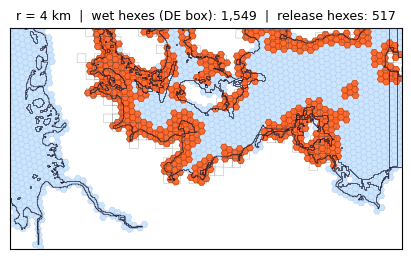

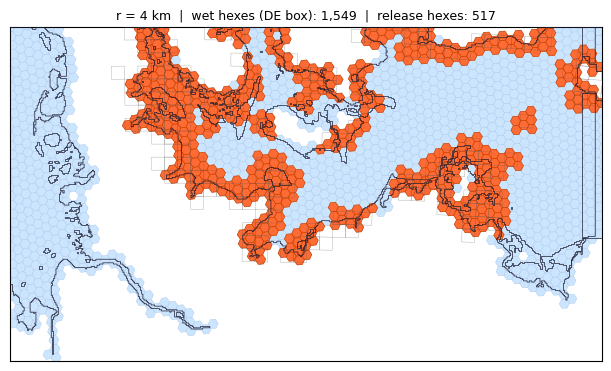

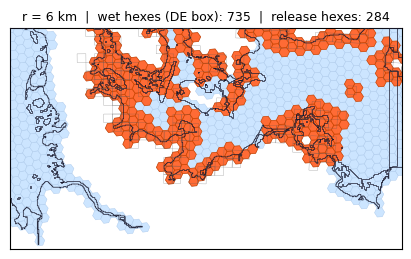

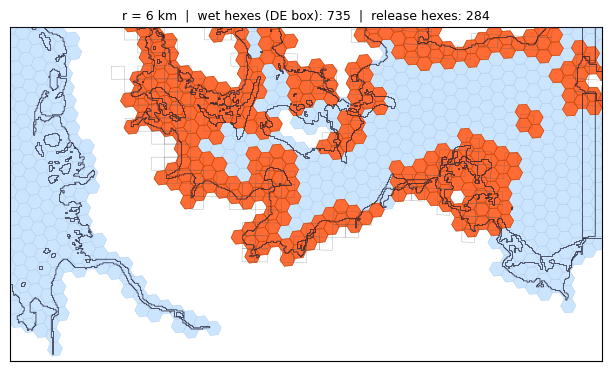

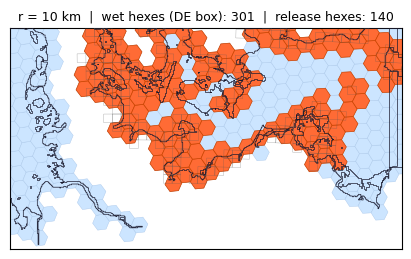

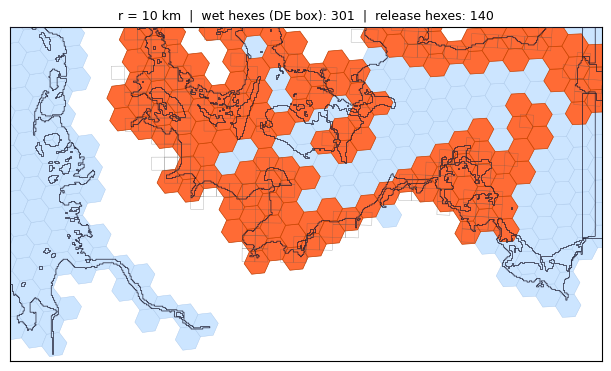

In [6]:
for r in candidate_radii_m:
    hp = HexProj(**hp_origin, hex_size_meters=r)

    # Decompose using the clipped wet region — same unified grid, German subset.
    wet_ids = hp.region_of_hexes(wet_de_union)
    wet_hex = hp.to_geodataframe(wet_ids).dropna(subset=["geometry"])

    # Release hexes: sjoin with Fucus cells in box.
    release_hex = gpd.sjoin(
        wet_hex,
        fucus_de_gdf[["geometry"]],
        how="inner",
        predicate="intersects",
    ).loc[lambda df: ~df.index.duplicated()]

    n_wet = len(wet_hex)
    n_rel = len(release_hex)

    title = (
        f"r = {r/1000:.0f} km  |  wet hexes (DE box): {n_wet:,}  |  release hexes: {n_rel:,}"
    )

    def _draw(figsize):
        fig, ax = plt.subplots(figsize=figsize, layout="constrained")
        wet_hex.plot(ax=ax, color="#cce5ff", edgecolor="#aac8ea", linewidth=0.3, zorder=1)
        release_hex.plot(ax=ax, color="#ff6b35", edgecolor="#cc4400", linewidth=0.5, zorder=2)
        always_wet_de_gdf.boundary.plot(ax=ax, color="#1a1a2e", linewidth=0.5, zorder=3)
        fucus_de_gdf.boundary.plot(ax=ax, color="#555555", linewidth=0.3, alpha=0.5, zorder=4)
        ax.set_xlim(lon_min, lon_max)
        ax.set_ylim(lat_min, lat_max)
        ax.set_aspect(1 / np.cos(np.radians(0.5 * (lat_min + lat_max))))
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(title, fontsize=9)
        plt.show()

    _draw((4, 4))   # small — check legibility at print/poster size
    _draw((6, 6))   # medium — check hex edge density